# COVID-19 Survey Outcome Classification

This collaborative data science project examines a 5,789-record subset of the Nexoid COVID-19 Survival Calculator dataset. The objective is to build a reproducible classification workflow that identifies patterns associated with the survey's binary `covid19_positive` outcome.

The analysis focuses on data quality, privacy-aware feature selection, leakage-safe preprocessing, model tuning, and honest held-out evaluation. It is an educational analysis and is not a clinical diagnostic tool.

## Data Source, Licence, and Collaboration

The source dataset was published by **Nexoid, United Kingdom** under the [Creative Commons Attribution 4.0 International licence](https://creativecommons.org/licenses/by/4.0/).

- Source: [Nexoid COVID-19 Survival Calculator dataset](https://www.covid19survivalcalculator.com/en/download)
- Project data: 5,789-record subset of the public source
- Changes: placeholder handling, missing-value treatment, feature exclusion, encoding, scaling, model tuning, and evaluation
- Attribution: Nexoid does not endorse this analysis

This project was developed collaboratively by three contributors. Contributor profiles are documented in the repository README and GitHub contribution history.

## 1. Setup and Reproducibility

In [1]:
from pathlib import Path
import json
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 10
PROJECT_ROOT = Path("..").resolve()
DATA_PATH = Path(os.environ.get("COVID_SURVEY_DATA", PROJECT_ROOT / "data" / "Dataset.csv"))

print(f"Pandas: {pd.__version__}")
import sklearn
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Data file: {DATA_PATH.name}")

Pandas: 2.2.3
Scikit-learn: 1.6.1
Data file: Dataset.csv


## 2. Load and Validate the Dataset

In [2]:
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Dataset.csv was not found. Place it in data/Dataset.csv or set "
        "the COVID_SURVEY_DATA environment variable."
    )

raw = pd.read_csv(DATA_PATH)
TARGET = "covid19_positive"
required_columns = {TARGET, "Participant_ID", "risk_infection", "risk_mortality"}
missing_required = required_columns.difference(raw.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {sorted(missing_required)}")

validation_summary = pd.Series(
    {
        "Records": len(raw),
        "Variables": raw.shape[1],
        "Duplicate rows": int(raw.duplicated().sum()),
        "Unique participant IDs": int(raw["Participant_ID"].nunique()),
        "Positive outcomes": int(raw[TARGET].sum()),
        "Positive outcome rate": f"{raw[TARGET].mean():.1%}",
    },
    name="Value",
)
display(validation_summary.to_frame())

,Value
Records,5789
Variables,38
Duplicate rows,0
Unique participant IDs,5789
Positive outcomes,2335
Positive outcome rate,40.3%


The notebook deliberately avoids displaying participant-level rows. The public analysis uses aggregated summaries and excludes participant identifiers and coordinates from modelling.

## 3. Data Types and Quality Audit

In [3]:
schema = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "missing": raw.isna().sum(),
        "missing_pct": (raw.isna().mean() * 100).round(1),
        "unique_values": raw.nunique(dropna=True),
    }
)
display(schema)

placeholder_counts = {
    "question_mark": int(raw.astype(str).eq("?").sum().sum()),
    "blank_label": int(raw.astype(str).eq("blank").sum().sum()),
}
print("Placeholder counts:", placeholder_counts)

,dtype,missing,missing_pct,unique_values
Participant_ID,int64,0,0.0,5789
survey_date,object,0,0.0,120
region,object,15,0.3,7
country,object,3,0.1,94
ip_latitude,float64,0,0.0,5697
ip_longitude,float64,0,0.0,5733
gender,object,0,0.0,3
age,object,0,0.0,9
height,int64,0,0.0,49
weight,int64,0,0.0,68


Placeholder counts: {'question_mark': 26, 'blank_label': 453}


,missing,missing_pct
cocaine,4359,75.3
insurance,1623,28.0
income,1275,22.0
worried,1271,22.0
public_transport_count,1217,21.0
blood_type,100,1.7
contacts_count,42,0.7
working,42,0.7
smoking,36,0.6
region,27,0.5


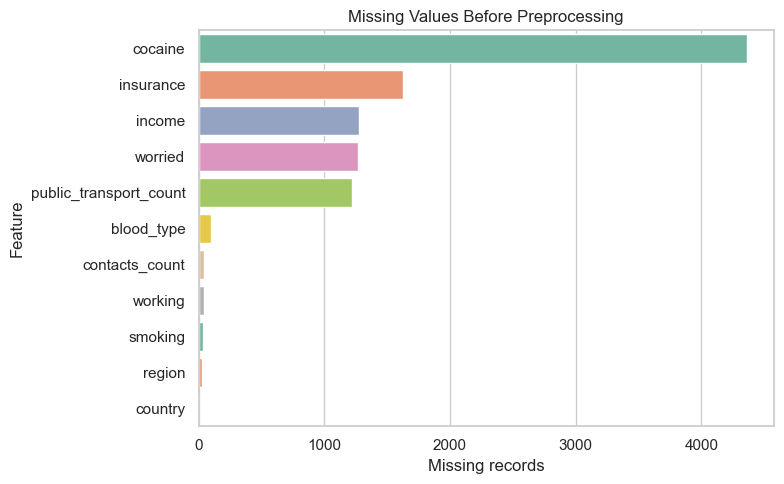

In [4]:
data = raw.replace({"?": np.nan, "blank": np.nan}).copy()

missing_summary = (
    data.isna()
    .sum()
    .rename("missing")
    .to_frame()
    .assign(missing_pct=lambda x: (x["missing"] / len(data) * 100).round(1))
    .query("missing > 0")
    .sort_values("missing", ascending=False)
)
display(missing_summary)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=missing_summary.reset_index(),
    x="missing",
    y="index",
    hue="index",
    palette="Set2",
    legend=False,
)
ax.set(title="Missing Values Before Preprocessing", xlabel="Missing records", ylabel="Feature")
plt.tight_layout()
plt.show()

Missing values are handled inside the modelling pipeline rather than being filled across the entire dataset. This ensures that imputation values are learned only from each training fold.

## 4. Focused Exploratory Analysis

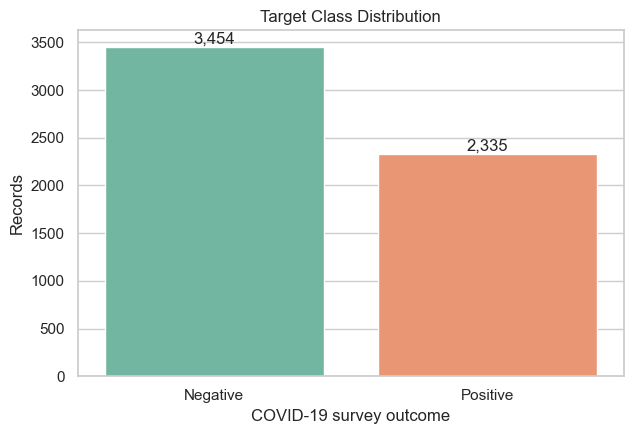

In [5]:
target_counts = data[TARGET].value_counts().sort_index()
target_labels = ["Negative", "Positive"]

plt.figure(figsize=(6.5, 4.5))
ax = sns.barplot(x=target_labels, y=target_counts.values, hue=target_labels, palette="Set2", legend=False)
ax.set(title="Target Class Distribution", xlabel="COVID-19 survey outcome", ylabel="Records")
for index, value in enumerate(target_counts.values):
    ax.text(index, value + 35, f"{value:,}", ha="center")
plt.tight_layout()
plt.show()

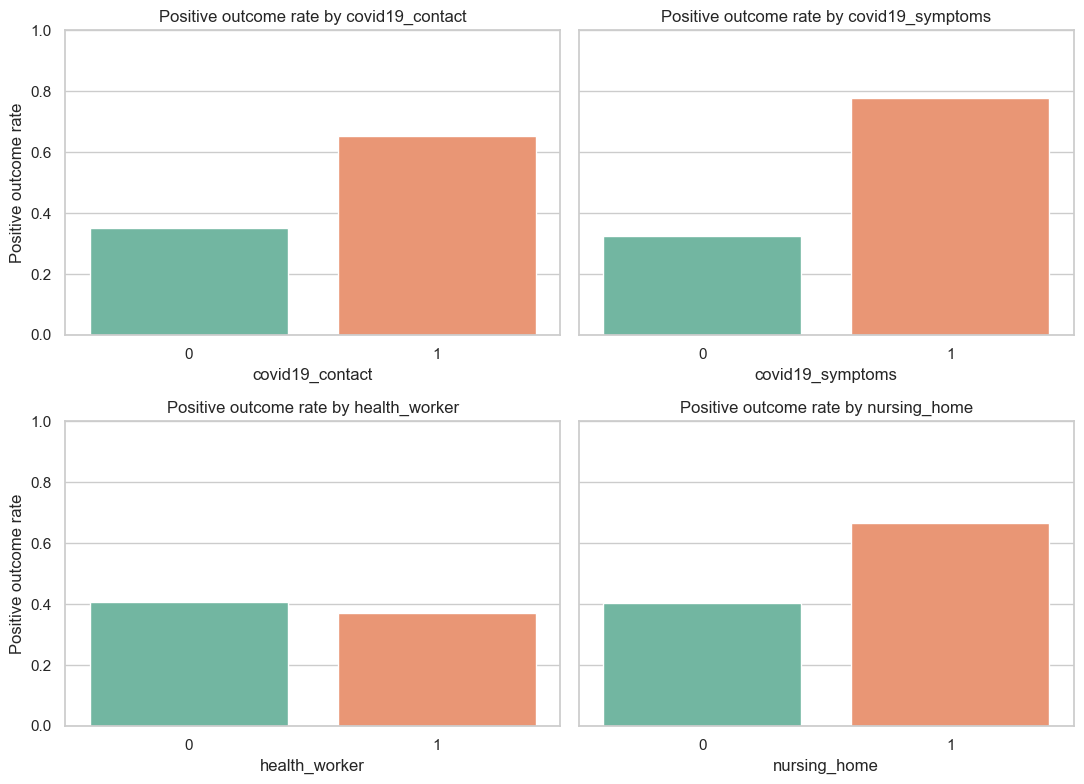

In [6]:
association_features = [
    "covid19_contact",
    "covid19_symptoms",
    "health_worker",
    "nursing_home",
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharey=True)
for feature, ax in zip(association_features, axes.flat):
    rates = data.groupby(feature, dropna=False)[TARGET].mean().reset_index()
    rates[feature] = rates[feature].astype(str)
    sns.barplot(data=rates, x=feature, y=TARGET, hue=feature, palette="Set2", legend=False, ax=ax)
    ax.set_title(f"Positive outcome rate by {feature}")
    ax.set_xlabel(feature)
    ax.set_ylabel("Positive outcome rate")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

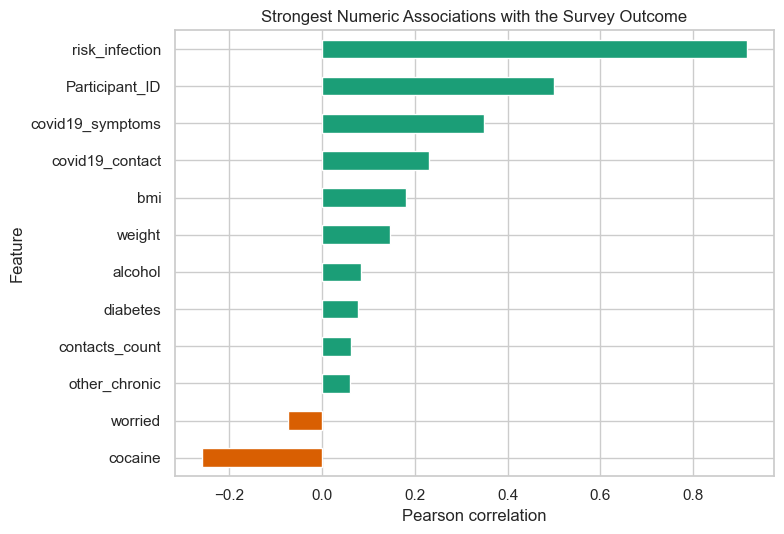

,correlation
cocaine,-0.258750
worried,-0.072524
other_chronic,0.060624
contacts_count,0.063288
diabetes,0.078499
alcohol,0.083460
weight,0.146007
bmi,0.180313
covid19_contact,0.231168
covid19_symptoms,0.348659


In [7]:
numeric_data = data.select_dtypes(include="number")
target_correlations = (
    numeric_data.corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .head(12)
    .sort_values()
)

plt.figure(figsize=(8, 5.5))
colors = ["#d95f02" if value < 0 else "#1b9e77" for value in target_correlations.values]
target_correlations.plot(kind="barh", color=colors)
plt.title("Strongest Numeric Associations with the Survey Outcome")
plt.xlabel("Pearson correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(target_correlations.rename("correlation").to_frame())

The plots describe associations within a self-selected survey sample. They do not establish causal relationships or clinical risk factors.

## 5. Feature Selection and Leakage Review

In [8]:
feature_decisions = pd.DataFrame(
    [
        ("Participant_ID", "Exclude", "Identifier with no generalisable predictive meaning"),
        ("survey_date", "Exclude", "Time effects are outside the defined prediction use case"),
        ("ip_latitude / ip_longitude", "Exclude", "Privacy and limited geographic generalisability"),
        ("risk_infection", "Exclude", "Precomputed calculator score that may proxy the target"),
        ("risk_infection_level", "Exclude", "Categorised version of a precomputed risk score"),
        ("risk_mortality", "Exclude", "Precomputed calculator output rather than a raw survey response"),
        ("Symptoms, contacts, behaviours", "Retain", "Survey responses available at prediction time"),
        ("Health-condition flags", "Retain", "Survey responses available at prediction time"),
    ],
    columns=["Feature group", "Decision", "Reason"],
)
display(feature_decisions)

,Feature group,Decision,Reason
0,Participant_ID,Exclude,Identifier with no generalisable predictive me...
1,survey_date,Exclude,Time effects are outside the defined predictio...
2,ip_latitude / ip_longitude,Exclude,Privacy and limited geographic generalisability
3,risk_infection,Exclude,Precomputed calculator score that may proxy th...
4,risk_infection_level,Exclude,Categorised version of a precomputed risk score
5,risk_mortality,Exclude,Precomputed calculator output rather than a ra...
6,"Symptoms, contacts, behaviours",Retain,Survey responses available at prediction time
7,Health-condition flags,Retain,Survey responses available at prediction time


## 6. Train-Test Split Before Preprocessing

In [9]:
EXCLUDED_COLUMNS = [
    "Participant_ID",
    "survey_date",
    "ip_latitude",
    "ip_longitude",
    "risk_infection",
    "risk_infection_level",
    "risk_mortality",
]

y = data[TARGET].astype(int)
X = data.drop(columns=[TARGET, *EXCLUDED_COLUMNS], errors="ignore")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE,
)

numeric_columns = X_train.select_dtypes(include="number").columns.tolist()
categorical_columns = X_train.select_dtypes(exclude="number").columns.tolist()

print(f"Input features before encoding: {X.shape[1]}")
print(f"Numeric features: {len(numeric_columns)}")
print(f"Categorical features: {len(categorical_columns)}")
print(f"Training records: {len(X_train):,}")
print(f"Test records: {len(X_test):,}")

Input features before encoding: 30
Numeric features: 21
Categorical features: 9
Training records: 4,052
Test records: 1,737


## 7. Leakage-Safe Preprocessing Pipeline

In [10]:
numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ]
)

def model_pipeline(classifier):
    return Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("classifier", classifier),
        ]
    )

print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['height', 'weight', 'bmi', 'alcohol',
                                  'cocaine', 'contacts_count',
                                  'public_transport_count', 'worried',
                                  'covid19_symptoms', 'covid19_contact',
                                  'asthma', 'kidney_disease', 'liver_disease',
                                  'compromised_immune', 'heart_disease',
                                  'lung_disease', 'diabetes', 'hiv_positive',
                                  'other_chronic', 'nursing_home',
                                  'health_worker']),
                                ('categorical',
                                 Pipeline(steps=[('i

## 8. Baseline, Cross-Validation, and Model Tuning

In [11]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

tree_search = GridSearchCV(
    estimator=model_pipeline(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    param_grid={
        "classifier__criterion": ["gini", "entropy"],
        "classifier__max_depth": [3, 5, 7, 10, None],
        "classifier__min_samples_leaf": [1, 5, 10, 20],
        "classifier__class_weight": [None, "balanced"],
    },
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

knn_search = GridSearchCV(
    estimator=model_pipeline(KNeighborsClassifier()),
    param_grid={
        "classifier__n_neighbors": [5, 9, 15, 25],
        "classifier__weights": ["uniform", "distance"],
        "classifier__p": [1, 2],
    },
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True,
    error_score="raise",
)

tree_search.fit(X_train, y_train)
knn_search.fit(X_train, y_train)

print("Decision Tree best CV F1:", round(tree_search.best_score_, 4))
print("KNN best CV F1:", round(knn_search.best_score_, 4))

Decision Tree best CV F1: 0.6912
KNN best CV F1: 0.6521


## 9. Held-Out Test Evaluation

In [12]:
def evaluate_model(name, estimator):
    predictions = estimator.predict(X_test)
    probabilities = estimator.predict_proba(X_test)[:, 1]
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test, predictions),
        "precision": precision_score(y_test, predictions, zero_division=0),
        "recall": recall_score(y_test, predictions, zero_division=0),
        "f1": f1_score(y_test, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_test, probabilities),
    }, predictions

baseline_metrics, baseline_predictions = evaluate_model("Baseline", baseline)
tree_metrics, tree_predictions = evaluate_model("Decision Tree", tree_search)
knn_metrics, knn_predictions = evaluate_model("KNN", knn_search)

results = pd.DataFrame([baseline_metrics, tree_metrics, knn_metrics]).set_index("model")
display(results.style.format("{:.3f}").highlight_max(axis=0, color="#d9ead3"))

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc
model,,,,,,
Baseline,0.596,0.500,0.000,0.000,0.000,0.500
Decision Tree,0.724,0.724,0.638,0.728,0.680,0.773
KNN,0.744,0.726,0.704,0.633,0.667,0.803


In [13]:
best_parameters = {
    "Decision Tree": tree_search.best_params_,
    "KNN": knn_search.best_params_,
}
print(json.dumps(best_parameters, indent=2))

{
  "Decision Tree": {
    "classifier__class_weight": "balanced",
    "classifier__criterion": "entropy",
    "classifier__max_depth": 5,
    "classifier__min_samples_leaf": 20
  },
  "KNN": {
    "classifier__n_neighbors": 9,
    "classifier__p": 1,
    "classifier__weights": "distance"
  }
}


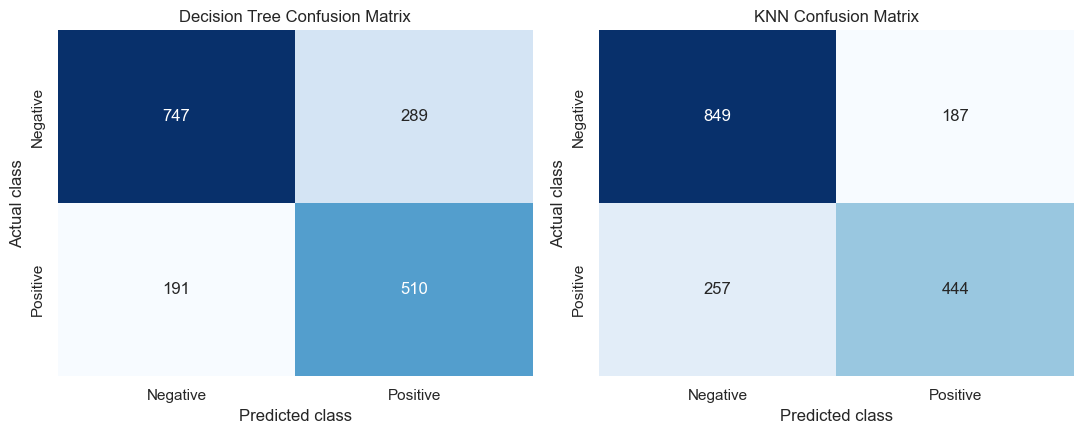

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, name, predictions in [
    (axes[0], "Decision Tree", tree_predictions),
    (axes[1], "KNN", knn_predictions),
]:
    matrix = confusion_matrix(y_test, predictions)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"],
        ax=ax,
    )
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")

plt.tight_layout()
plt.show()

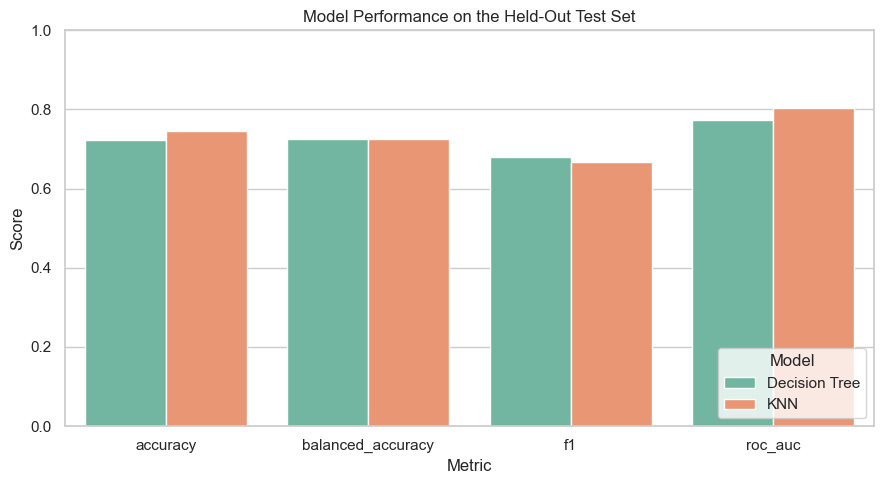

In [15]:
comparison = results.loc[["Decision Tree", "KNN"], ["accuracy", "balanced_accuracy", "f1", "roc_auc"]]
chart_data = comparison.reset_index().melt(id_vars="model", var_name="metric", value_name="score")

plt.figure(figsize=(9, 5))
ax = sns.barplot(data=chart_data, x="metric", y="score", hue="model", palette="Set2")
ax.set(title="Model Performance on the Held-Out Test Set", xlabel="Metric", ylabel="Score")
ax.set_ylim(0, 1)
ax.legend(title="Model", loc="lower right")
plt.tight_layout()
plt.show()

## 10. Model Interpretation

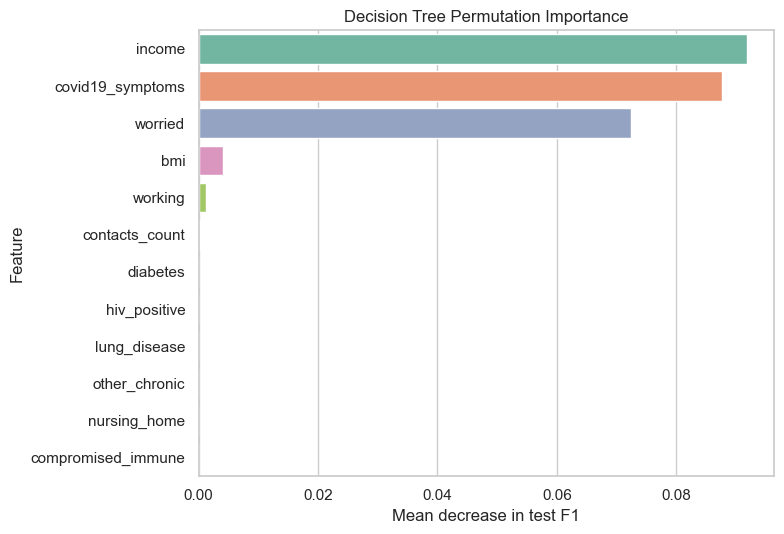

,feature,importance,std
9,income,0.091774,0.007040
17,covid19_symptoms,0.087640,0.003625
16,worried,0.072491,0.008480
6,bmi,0.004136,0.001097
15,working,0.001288,0.001815
13,contacts_count,0.000170,0.001173
25,diabetes,0.000000,0.000000
26,hiv_positive,0.000000,0.000000
24,lung_disease,0.000000,0.000000
27,other_chronic,0.000000,0.000000


In [16]:
importance = permutation_importance(
    tree_search.best_estimator_,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_table = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "importance": importance.importances_mean,
            "std": importance.importances_std,
        }
    )
    .sort_values("importance", ascending=False)
    .head(12)
)

plt.figure(figsize=(8, 5.5))
sns.barplot(data=importance_table, x="importance", y="feature", hue="feature", palette="Set2", legend=False)
plt.title("Decision Tree Permutation Importance")
plt.xlabel("Mean decrease in test F1")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

display(importance_table)

## 11. Conclusion and Limitations

In [17]:
print(
    f"Decision Tree: recall={tree_metrics['recall']:.3f}, F1={tree_metrics['f1']:.3f}, "
    f"ROC-AUC={tree_metrics['roc_auc']:.3f}"
)
print(
    f"KNN: accuracy={knn_metrics['accuracy']:.3f}, precision={knn_metrics['precision']:.3f}, "
    f"ROC-AUC={knn_metrics['roc_auc']:.3f}"
)
print(
    "The Decision Tree is retained as the primary demonstration model because it provides "
    "higher positive-class recall and F1 together with clearer interpretation."
)

Decision Tree: recall=0.728, F1=0.680, ROC-AUC=0.773
KNN: accuracy=0.744, precision=0.704, ROC-AUC=0.803
The Decision Tree is retained as the primary demonstration model because it provides higher positive-class recall and F1 together with clearer interpretation.


### Limitations

- The source is a self-selected, self-reported online survey and may contain selection and reporting bias.
- The method used to create the 5,789-record subset is not available.
- The binary outcome is a survey field and should not be interpreted as a clinically confirmed diagnosis without supporting documentation.
- Results are based on one held-out split and five-fold internal cross-validation; no external dataset was available for validation.
- Associations and feature importance describe this dataset and fitted models. They do not establish causality.

The models must not be used for diagnosis, treatment, or individual health decisions.